In [11]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

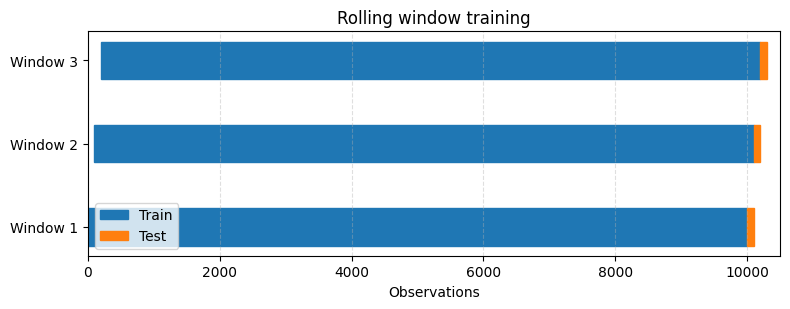

In [12]:
#Rolling window training visualization

WINDOW_SIZE = 10000
STEP = 100

# First three rolling windows
windows = []
for k in range(3):
    i = WINDOW_SIZE + k * STEP
    train_start = i - WINDOW_SIZE
    train_end = i
    test_start = i
    test_end = i + STEP
    windows.append((train_start, train_end, test_start, test_end))

fig, ax = plt.subplots(figsize=(8, 3.2))

y_labels = ["Window 1", "Window 2", "Window 3"]
y_positions = [0, 1, 2]

for y, (train_start, train_end, test_start, test_end) in zip(y_positions, windows):
    ax.barh(
        y,
        train_end - train_start,
        left=train_start,
        height=0.45,
        color="#1f77b4",
        edgecolor="#1f77b4",
        label="Train" if y == 0 else ""
    )
    ax.barh(
        y,
        test_end - test_start,
        left=test_start,
        height=0.45,
        color="#ff7f0e",
        edgecolor="#ff7f0e",
        label="Test" if y == 0 else ""
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Observations")
ax.set_title("Rolling window training")
ax.legend(loc="lower left")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlim(0, 10500)

plt.tight_layout()
plt.savefig("rollingwindow.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

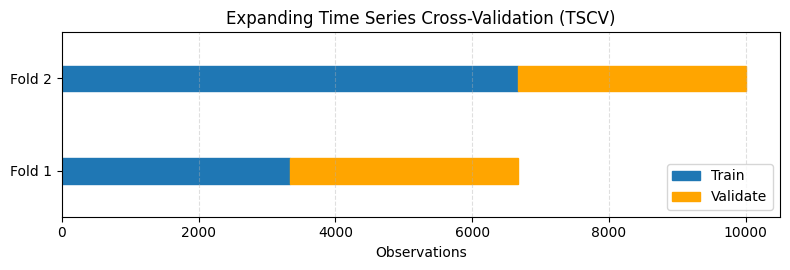

In [13]:
#Expanding TSCV visualization
WINDOW_SIZE = 10000
fold_size = WINDOW_SIZE // 3

folds = [
    (0, fold_size, fold_size, 2 * fold_size),
    (0, 2 * fold_size, 2 * fold_size, WINDOW_SIZE)
]

fig, ax = plt.subplots(figsize=(8, 2.8))

y_labels = ["Fold 1", "Fold 2"]
y_positions = [0, 1]

for y, (train_start, train_end, val_start, val_end) in zip(y_positions, folds):
    ax.barh(
        y,
        train_end - train_start,
        left=train_start,
        height=0.28,
        color="#1f77b4",
        edgecolor="#1f77b4",
        label="Train" if y == 0 else ""
    )
    ax.barh(
        y,
        val_end - val_start,
        left=val_start,
        height=0.28,
        color="orange",
        edgecolor="orange",
        label="Validate" if y == 0 else ""
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)

ax.set_xlabel("Observations")
ax.set_title("Expanding Time Series Cross-Validation (TSCV)", fontsize=12)

ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.set_xlim(0, 10500)
ax.set_ylim(-0.5, 1.5)

plt.tight_layout()

plt.savefig("expanding_tscv.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

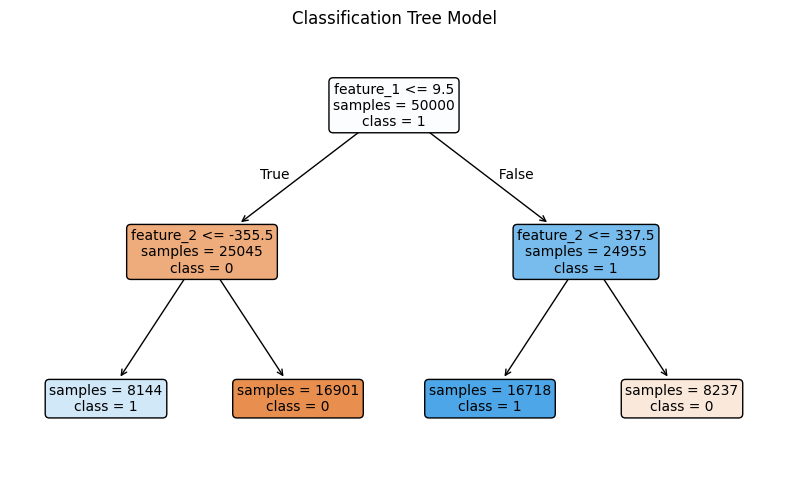

In [14]:
#Classification tree visualization
from sklearn.tree import DecisionTreeClassifier, plot_tree

np.random.seed(42)
n = 50000

# Two abstract features
feature_1 = np.random.randint(-1000, 1000, size=n)
feature_2 = np.random.randint(-1000, 1000, size=n)
X_vis = np.column_stack([feature_1, feature_2])

# Probabilistic target
logit = feature_1 / 220 - feature_2 / 260
p = 1 / (1 + np.exp(-logit))
y = (np.random.rand(n) < p).astype(int)

#Tree
tree_vis = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=500,
    random_state=1
)

tree_vis.fit(X_vis, y)

fig, ax = plt.subplots(figsize=(8, 5))

plot_tree(
    tree_vis,
    feature_names=["feature_1", "feature_2"],
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=10,
    ax=ax
)

#Remove value row
for text in ax.texts:
    label = text.get_text()
    lines = label.split("\n")
    lines = [line for line in lines if not line.strip().startswith("value")]
    text.set_text("\n".join(lines))

plt.title("Classification Tree Model", fontsize=12)
plt.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

plt.savefig("classification_tree_generic.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

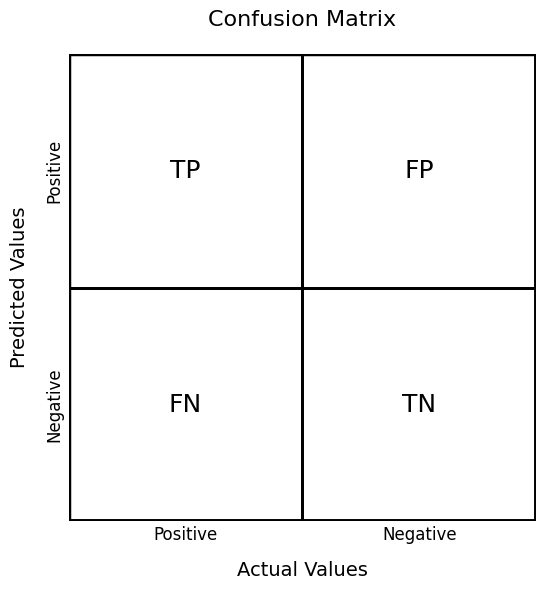

In [15]:
#Confusion matrix visualization
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 6))

#2x2 grid
for i in range(2):
    for j in range(2):
        rect = Rectangle((j, 1 - i), 1, 1, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(rect)

#Strengthen outer borders
ax.plot([0, 2], [2, 2], color="black", linewidth=2.5)  # top
ax.plot([0, 2], [0, 0], color="black", linewidth=2.5)  # bottom
ax.plot([0, 0], [0, 2], color="black", linewidth=2.5)  # left
ax.plot([2, 2], [0, 2], color="black", linewidth=2.5)  # right

#Cell labels
ax.text(0.5, 1.5, "TP", ha="center", va="center", fontsize=18)
ax.text(1.5, 1.5, "FP", ha="center", va="center", fontsize=18)
ax.text(0.5, 0.5, "FN", ha="center", va="center", fontsize=18)
ax.text(1.5, 0.5, "TN", ha="center", va="center", fontsize=18)

#Axis labels
ax.set_xlabel("Actual Values", fontsize=14, labelpad=12)
ax.set_ylabel("Predicted Values", fontsize=14, labelpad=12)

#Tick labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Positive", "Negative"], fontsize=12)

ax.set_yticks([1.5, 0.5])
ax.set_yticklabels(["Positive", "Negative"], fontsize=12, rotation=90, va="center")
outer = Rectangle((0, 0), 2, 2, fill=False, edgecolor="black", linewidth=2.8, zorder=10)
ax.add_patch(outer)
#Title
ax.set_title("Confusion Matrix", fontsize=16, pad=20)

#Style
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect("equal")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()
plt.savefig("confusion_matrix.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()